# MLOPS Assignment 1

Student: 2025AE05188

## 01. Data Acquisition & Exploratory Data Analysis

### Imports

In [ ]:
!pip3 install -U ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Download the dataset (Heart Disease UCI Dataset)

In [ ]:
# UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

Extract meta data

In [ ]:
print(heart_disease.metadata.additional_info.summary)
print(heart_disease.metadata.additional_info.purpose)
print(heart_disease.metadata.additional_info.preprocessing_description)

This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  
   
The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.

To see Test Costs (donated by Peter Turney), please see the folder "Costs" 
None
None


In [ ]:
print("UCI ID:", heart_disease.metadata.uci_id)
print("Dataset:", heart_disease.metadata.name)
print("Instances:", heart_disease.metadata.num_instances)
print("Features:", heart_disease.metadata.num_features)
print("Task:", heart_disease.metadata.task)
print("Feature types:", heart_disease.metadata.feature_types)
print("Target:", heart_disease.metadata.target_col)
print("Has missing values:", heart_disease.metadata.has_missing_values)
print("Missing value symbol:", heart_disease.metadata.missing_values_symbol)

UCI ID: 45
Dataset: Heart Disease
Instances: 303
Features: 13
Task: None
Feature types: ['Categorical', 'Integer', 'Real']
Target: ['num']
Has missing values: yes
Missing value symbol: NaN


In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [ ]:
display(heart_disease.variables)

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


We have missing values in features ca and thal. As the ca has numeric but limited set of values and thal is categorical. So, we can do mode imputation.

### Preprocess and EDA

In [ ]:
df = pd.concat([X, y], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


#### Preprocessing

For num column. (target column)

0 → absence of heart disease

1–4 → presence of heart disease

In [ ]:
df["target"] = (df["num"] > 0).astype(int)
df[["num", "target"]].head()

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


**Missing values**

In [ ]:
# Missing values per column
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
ca,4
thal,2


In [ ]:
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct[missing_pct > 0]

,0
ca,1.320132
thal,0.660066


We have a very small percentage of values missing, so either we can drop the records or impute with mode values. As we have only 303 records, lets not remove any record, rather we will go for mode imputation.

**Duplicate records**

In [ ]:
df.duplicated().sum()

np.int64(0)

There is no duplicate records found in the dataset.

**Unique values**

In [ ]:
for column in df.columns:
    print(f"\n{column}: {df[column].nunique()}")


age: 41

sex: 2

cp: 4

trestbps: 50

chol: 152

fbs: 2

restecg: 3

thalach: 91

exang: 2

oldpeak: 40

slope: 3

ca: 4

thal: 3

num: 5

target: 2


In [ ]:

features_set = {}
for feature_kind, features in heart_disease.variables.groupby("type")[['name']]:
  print(f"\n{feature_kind}:")
  features = features.values.flatten()
  print(features)
  features_set[feature_kind] = features


Categorical:
['sex' 'cp' 'fbs' 'restecg' 'exang' 'slope' 'thal']

Integer:
['age' 'trestbps' 'chol' 'thalach' 'oldpeak' 'ca' 'num']


From the features metadata, we can clearly see the numeric and categorical features. But, remove 'num' from features as its the target.

In [ ]:
if 'Integer' in features_set:
    features_set['Integer'] = np.delete(features_set['Integer'], np.where(features_set['Integer'] == 'num'))

print("Updated features_set:")
for key, val in features_set.items():
    print(f"{key}: {val}")

Updated features_set:
Categorical: ['sex' 'cp' 'fbs' 'restecg' 'exang' 'slope' 'thal']
Integer: ['age' 'trestbps' 'chol' 'thalach' 'oldpeak' 'ca']


**Target counts**

In [ ]:
df["target"].value_counts()

,count
target,
0,164
1,139


In [ ]:
df["target"].value_counts(normalize=True).mul(100).round(2)

,proportion
target,
0,54.13
1,45.87


We can say that we have a reasonable balanced dataset.

In [ ]:
print("Age range:", df["age"].min(), "-", df["age"].max())
print("Sex values:", df["sex"].dropna().unique())
print("CP values:", df["cp"].dropna().unique())
print("FBS values:", df["fbs"].dropna().unique())
print("Exang values:", df["exang"].dropna().unique())
print("Target values:", df["target"].unique())

Age range: 29 - 77
Sex values: [1 0]
CP values: [1 4 3 2]
FBS values: [1 0]
Exang values: [0 1]
Target values: [0 1]


**Handle missing values**

In [ ]:
for column in ["ca", "thal"]:
    print(df[column].value_counts(dropna=False).sort_index())

ca
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64
thal
3.0    166
6.0     18
7.0    117
NaN      2
Name: count, dtype: int64


`ca` and `thal` contain a small number of missing values and have a limited set of discrete values. Mode imputation is appropriate here because it preserves all patient records while replacing missing values with the most frequently observed category.


In [ ]:
for column in ["ca", "thal"]:
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)

    print(f"{column}: missing values filled with {mode_value}")

ca: missing values filled with 0.0
thal: missing values filled with 3.0


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
print("Missing values after imputation:")
print(df.isnull().sum().sum())

print("\nca distribution:")
print(df["ca"].value_counts().sort_index())

print("\nthal distribution:")
print(df["thal"].value_counts().sort_index())

Missing values after imputation:
0

ca distribution:
ca
0.0    180
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

thal distribution:
thal
3.0    168
6.0     18
7.0    117
Name: count, dtype: int64


In [ ]:
# Impute categorical missing values
for column in ["ca", "thal"]:
    df[column] = df[column].fillna(df[column].mode()[0])

#### EDA

The EDA is performed to understand the target distribution, feature distributions, potential outliers, relationships between features and the target, and relationships among input features.

The analysis includes target distribution, numerical and categorical feature distributions, feature–target relationships, and feature correlation analysis.


**Target distribution**

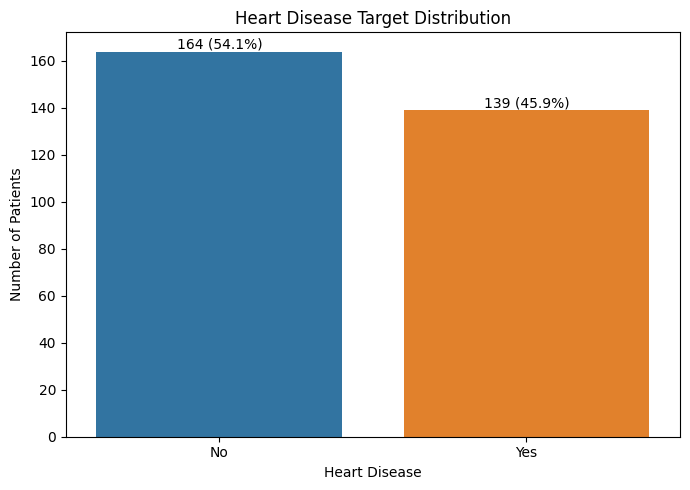

In [ ]:
def plot_target_distribution(df, target_col="target"):
    plt.figure(figsize=(7, 5))

    ax = sns.countplot(
        data=df,
        x=target_col,
        hue=target_col,
        legend=False,
    )

    total = len(df)

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{int(bar.get_height())} "
                f"({bar.get_height() / total:.1%})"
                for bar in container
            ],
        )

    plt.title("Heart Disease Target Distribution")
    plt.xlabel("Heart Disease")
    plt.ylabel("Number of Patients")
    plt.xticks([0, 1], ["No", "Yes"])
    plt.tight_layout()
    plt.show()


plot_target_distribution(df)

**Numeric features distributions**

In [ ]:
numerical_features = features_set["Integer"]

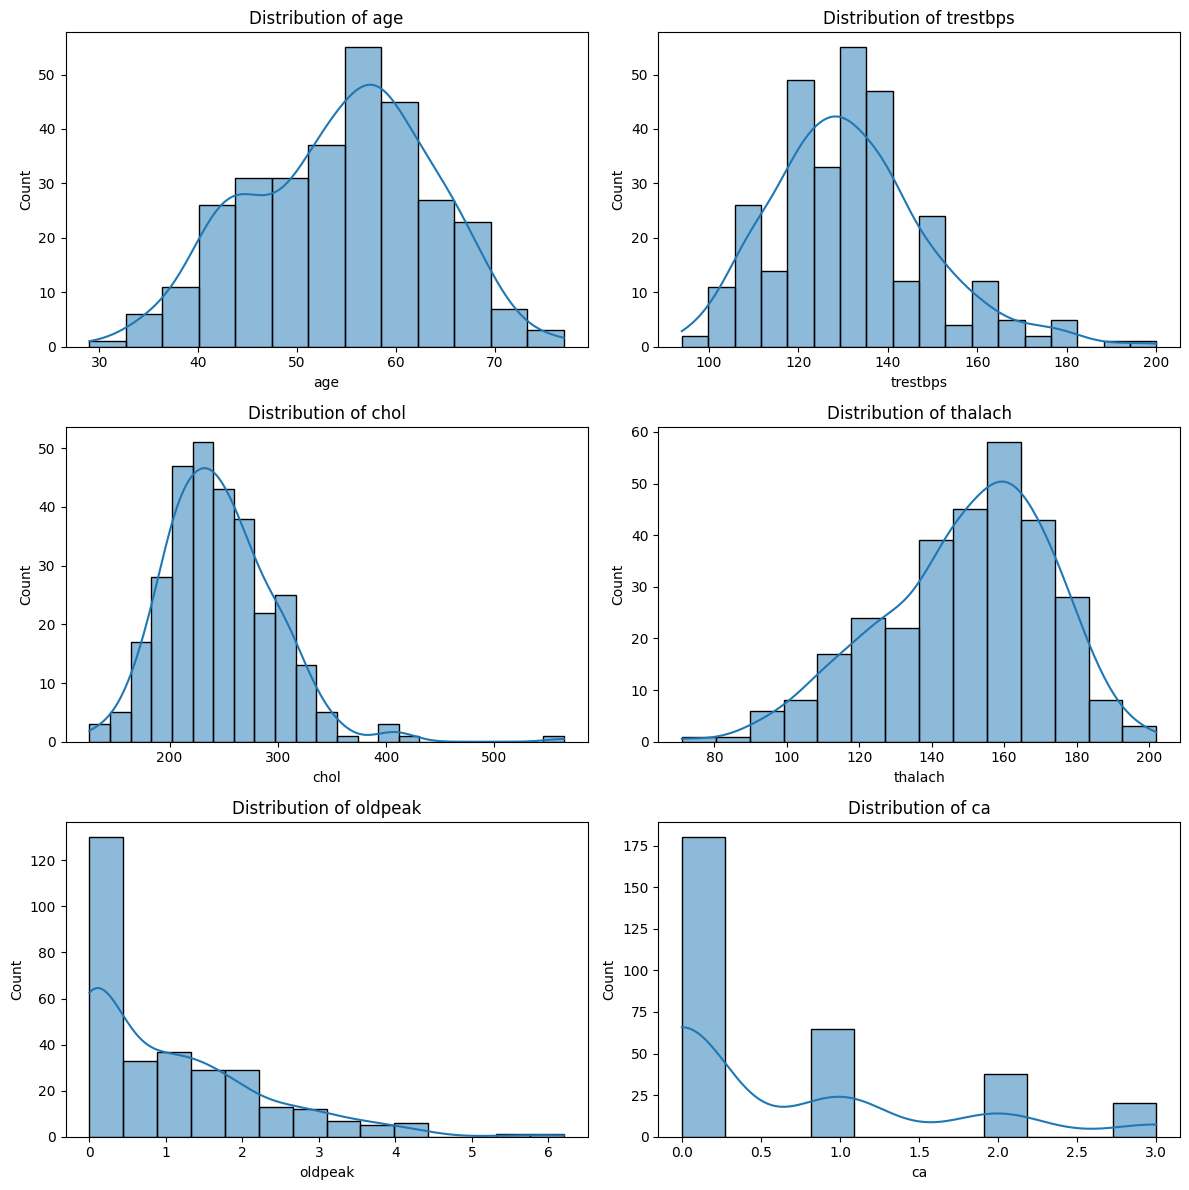

In [ ]:
def plot_numeric_distributions(df, features):
    n = len(features)
    fig, axes = plt.subplots(
        nrows=(n + 1) // 2,
        ncols=2,
        figsize=(12, 4 * ((n + 1) // 2)),
    )

    axes = np.array(axes).flatten()

    for ax, feature in zip(axes, features):
        sns.histplot(
            data=df,
            x=feature,
            kde=True,
            ax=ax,
        )
        ax.set_title(f"Distribution of {feature}")

    for ax in axes[len(features):]:
        ax.remove()

    plt.tight_layout()
    plt.show()


plot_numeric_distributions(df, numerical_features)

The numerical features show different distribution patterns. `age` is centered around the middle age range, while `trestbps` and `chol` show some right skew. `thalach` is slightly left-skewed. `oldpeak` is strongly right-skewed, with many observations concentrated near 0.

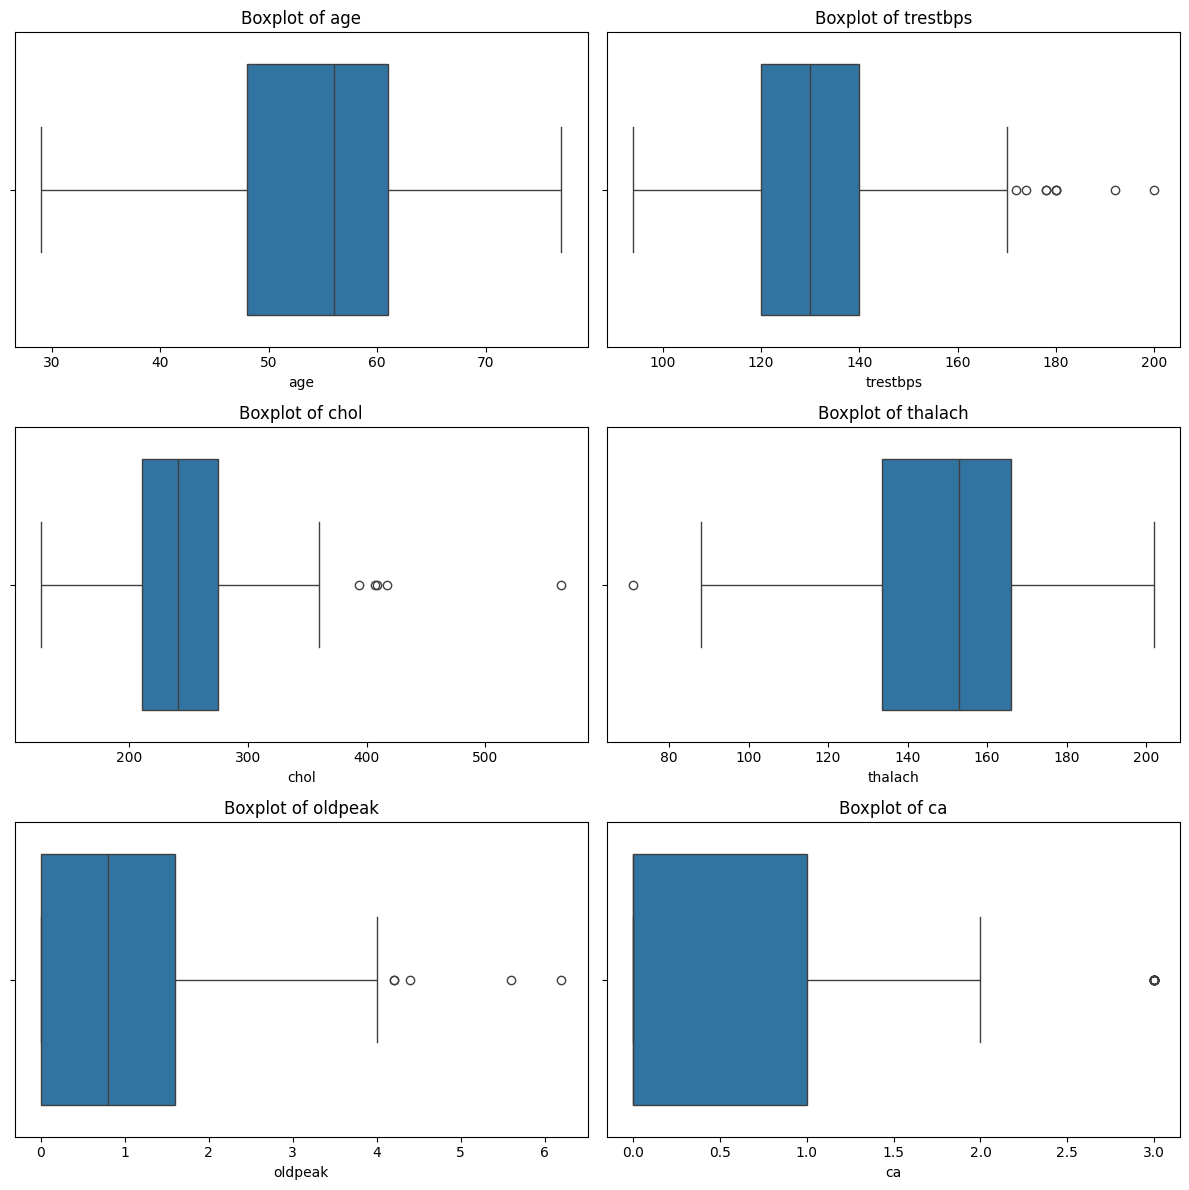

In [ ]:
def plot_numeric_boxplots(df, features):
    n = len(features)

    fig, axes = plt.subplots(
        nrows=(n + 1) // 2,
        ncols=2,
        figsize=(12, 4 * ((n + 1) // 2)),
    )

    axes = np.array(axes).flatten()

    for ax, feature in zip(axes, features):
        sns.boxplot(
            data=df,
            x=feature,
            ax=ax,
        )

        ax.set_title(f"Boxplot of {feature}")
        ax.set_xlabel(feature)

    # Remove unused subplots
    for ax in axes[len(features):]:
        ax.remove()

    plt.tight_layout()
    plt.show()


plot_numeric_boxplots(df, numerical_features)

The boxplots show potential outliers in `trestbps`, `chol`, `thalach`, and `oldpeak`, with more noticeable extreme values in `chol` and `oldpeak`.

These observations will not be removed automatically because statistical outliers may represent valid patient measurements. Their effect can be evaluated later through preprocessing and model experiments.


**Categorical features distributions**

In [ ]:
categorical_features = features_set["Categorical"]

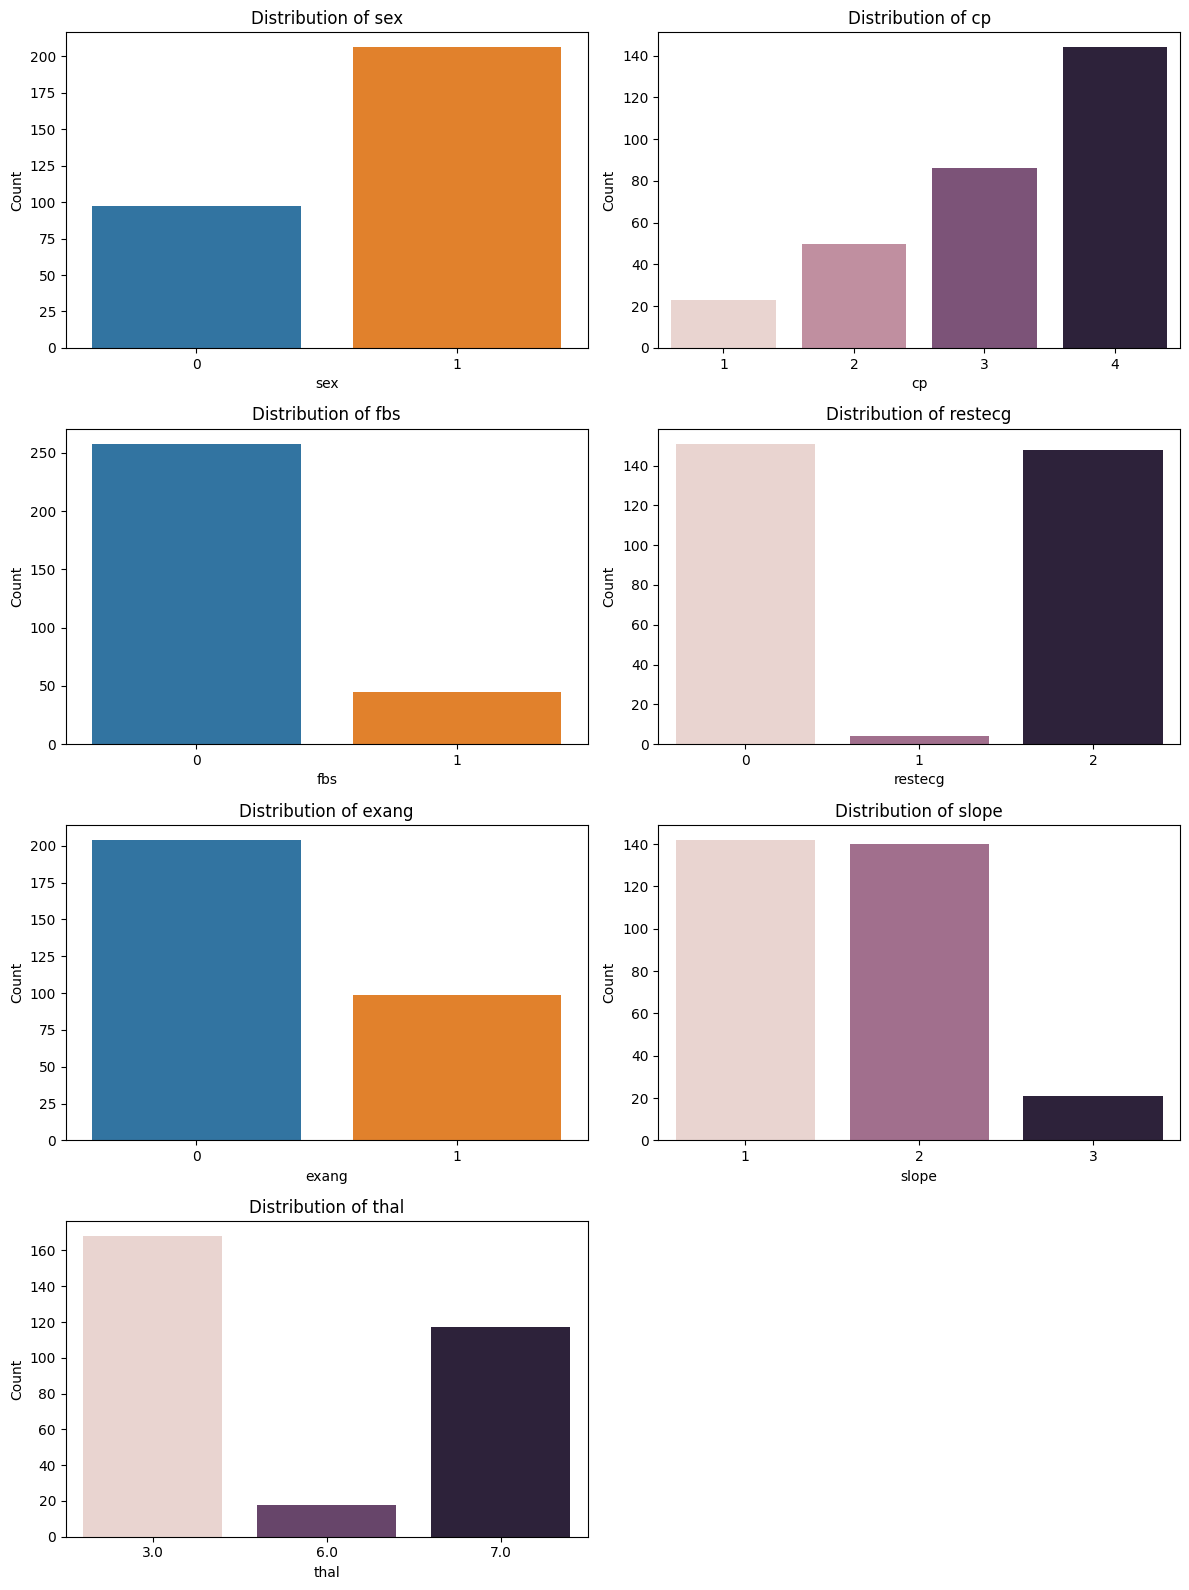

In [ ]:
def plot_categorical_distributions(df, features):
    n = len(features)
    fig, axes = plt.subplots(
        nrows=(n + 1) // 2,
        ncols=2,
        figsize=(12, 4 * ((n + 1) // 2)),
    )

    axes = np.array(axes).flatten()

    for ax, feature in zip(axes, features):
        sns.countplot(
            data=df,
            x=feature,
            hue=feature,
            legend=False,
            ax=ax,
        )
        ax.set_title(f"Distribution of {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Count")

    # Remove unused subplots
    for ax in axes[len(features):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

plot_categorical_distributions(df, categorical_features)

The categorical features have different frequency distributions across their categories. The dataset contains more male than female patients, while some categories of `cp`, `restecg`, `slope`, `ca`, and `thal` occur more frequently than others.

These differences indicate that the categorical variables are not uniformly distributed. Since the category codes represent discrete groups rather than continuous numerical values, their distributions should be interpreted by category rather than by the magnitude of the encoded value.


**Target correlation with features**

In [ ]:
feature_columns = [
    col for col in df.columns
    if col not in ["num", "target"]
]

target_correlation = (
    df[feature_columns + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

target_correlation

,target
thal,0.522057
ca,0.460033
exang,0.431894
oldpeak,0.424510
thalach,-0.417167
cp,0.414446
slope,0.339213
sex,0.276816
age,0.223120
restecg,0.169202


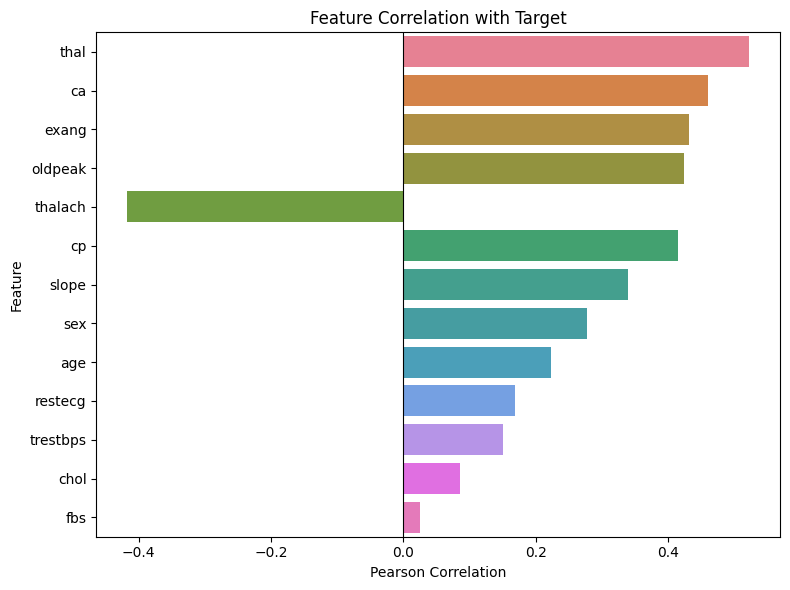

In [ ]:
def plot_target_correlation(correlation):
    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=correlation.values,
        y=correlation.index,
        hue=correlation.index,
        legend=False,
    )

    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Feature Correlation with Target")
    plt.xlabel("Pearson Correlation")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


plot_target_correlation(target_correlation)

The initial Pearson correlation screening shows the largest absolute associations with the target for `thal`, `ca`, `exang`, `oldpeak`, `thalach`, and `cp`.

`thal`, `ca`, `exang`, `oldpeak`, and `cp` have positive correlations, while `thalach` has a negative correlation. However, these correlation values should be treated only as an initial screening because several features are categorical and their numeric codes do not represent continuous measurements.


**Important features and EDA**

In [ ]:
important_features = (
    target_correlation.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

important_features

['thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp']

**Numeric fatures Vs Target and Categorical fatures Vs Target**

In [ ]:
def plot_numeric_vs_target(df, feature, target_col="target"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.boxplot(
        data=df,
        x=target_col,
        y=feature,
        hue=target_col,
        legend=False,
        ax=axes[0],
    )

    axes[0].set_title(f"{feature} vs Target")

    sns.histplot(
        data=df,
        x=feature,
        hue=target_col,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[1],
    )

    axes[1].set_title(f"{feature} Distribution by Target")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_categorical_vs_target(df, feature, target_col="target"):
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue=target_col,
    )

    plt.title(f"{feature} vs Target")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

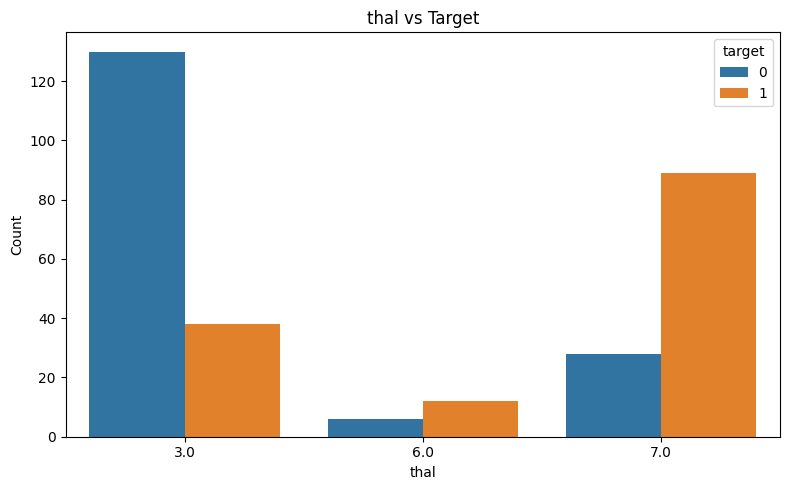

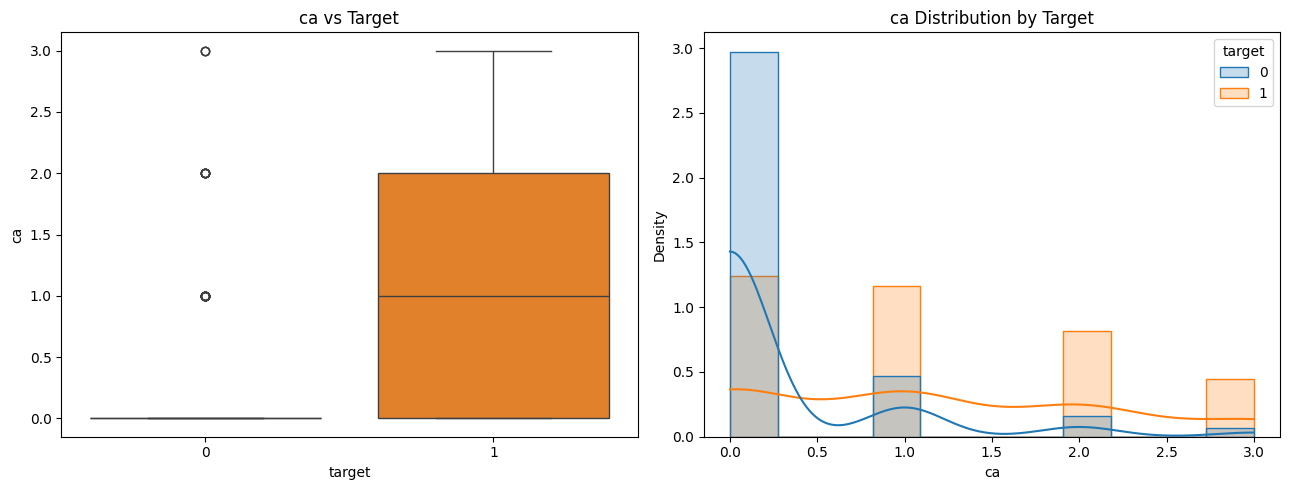

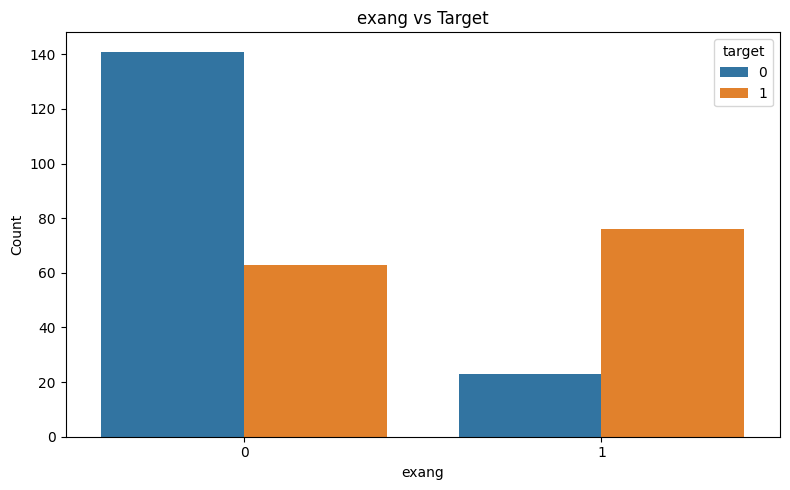

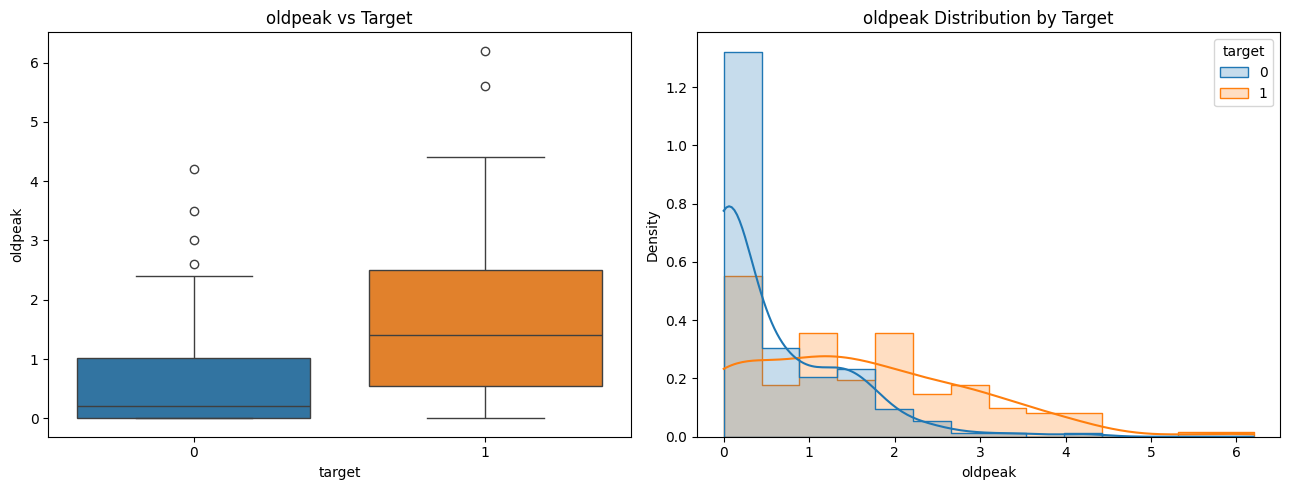

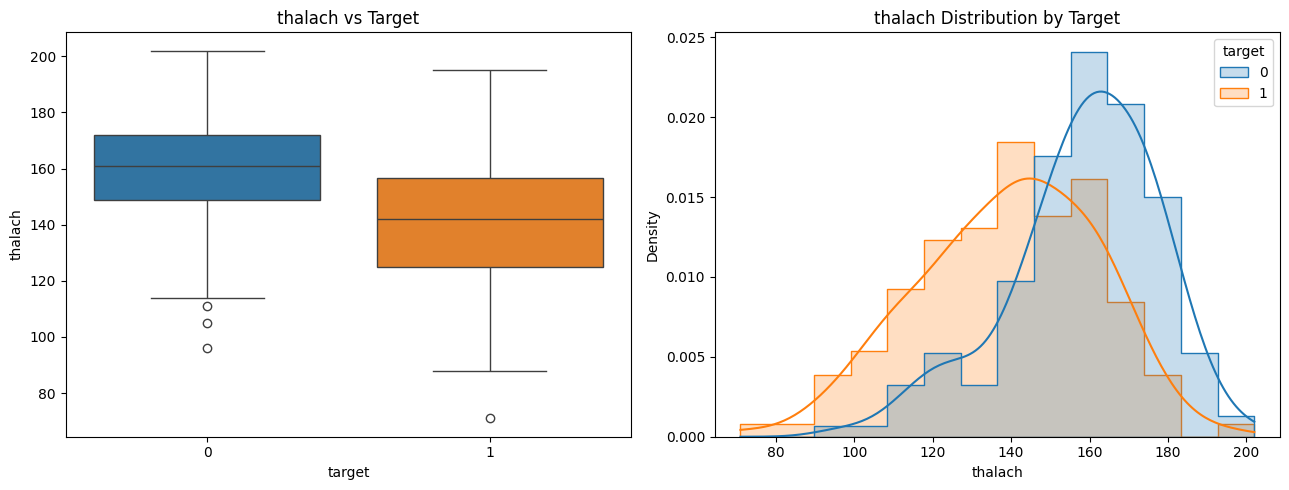

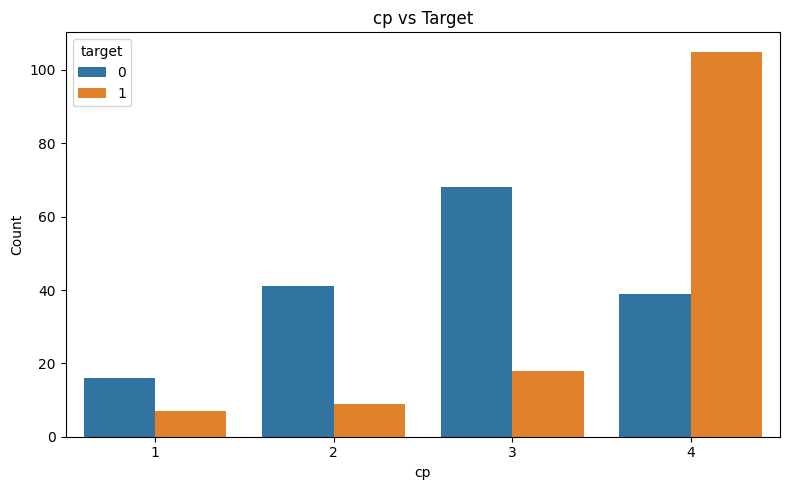

In [ ]:
for feature in important_features:
    if feature in numerical_features:
        plot_numeric_vs_target(df, feature)
    else:
        plot_categorical_vs_target(df, feature)

The feature-versus-target plots show noticeable differences in target distribution across several categorical features, particularly `thal`, `ca`, `exang`, and `cp`.

For the numerical features, `oldpeak` tends to be higher for positive cases, while `thalach` tends to be lower for positive cases. These patterns suggest potentially useful relationships, but the final contribution of each feature will be evaluated during model development and feature-selection experiments.


**Feature to feature Correlation**

In [ ]:
feature_corr = df[feature_columns].corr()

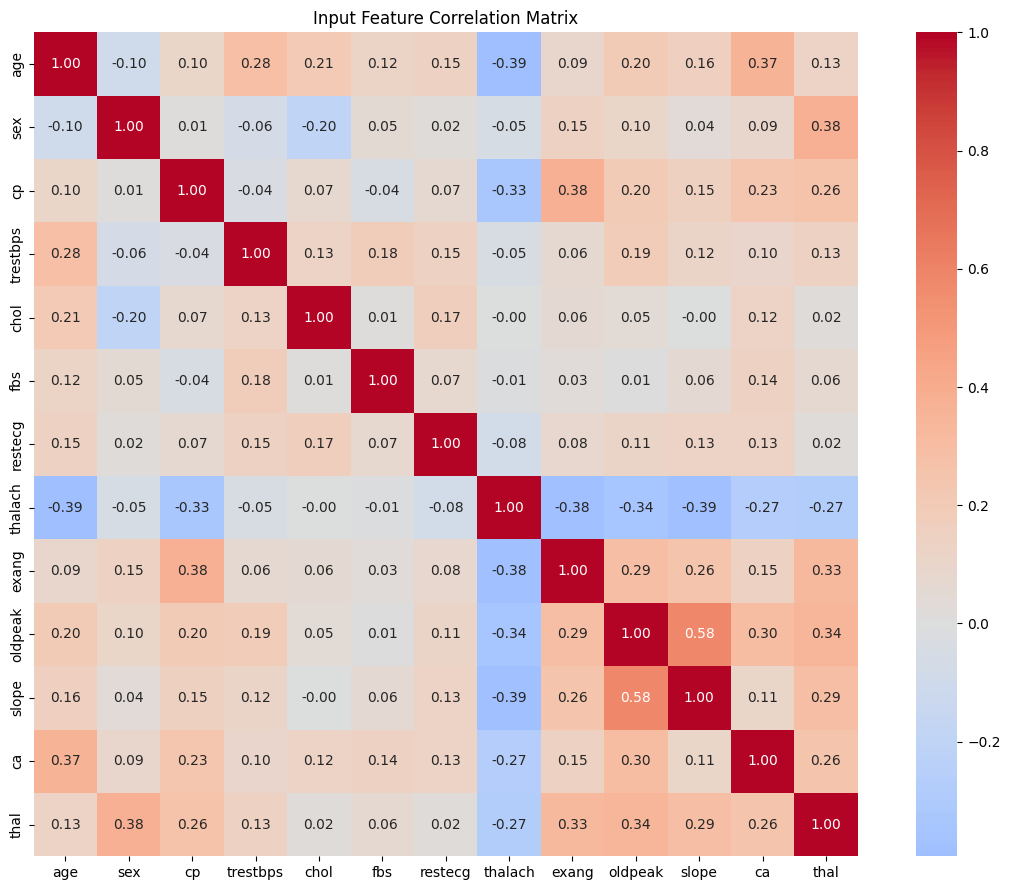

In [ ]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Input Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Extract highly correlated features**

In [ ]:
def get_highly_correlated_pairs(
    correlation_matrix,
    threshold=0.5,
):
    upper = correlation_matrix.where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1,
        ).astype(bool)
    )

    pairs = (
        upper.stack()
        .reset_index()
    )

    pairs.columns = [
        "feature_1",
        "feature_2",
        "correlation",
    ]

    pairs["abs_correlation"] = pairs["correlation"].abs()

    return (
        pairs[pairs["abs_correlation"] >= threshold]
        .sort_values(
            "abs_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [ ]:
high_corr_pairs = get_highly_correlated_pairs(
    feature_corr,
    threshold=0.5,
)

high_corr_pairs

,feature_1,feature_2,correlation,abs_correlation
0,oldpeak,slope,0.577537,0.577537


In [ ]:
def plot_feature_pair(df, feature_1, feature_2, target_col="target"):
    """
    Plot the relationship between two features based on their types.

    Supports:
    - Numerical vs Numerical   -> scatter plot
    - Categorical vs Categorical -> count/stacked proportion plot
    - Numerical vs Categorical -> box plot
    """

    feature_1_numeric = feature_1 in numerical_features
    feature_2_numeric = feature_2 in numerical_features

    # ---------------------------------------------------------
    # Numerical vs Numerical
    # ---------------------------------------------------------
    if feature_1_numeric and feature_2_numeric:
        plt.figure(figsize=(8, 6))

        sns.scatterplot(
            data=df,
            x=feature_1,
            y=feature_2,
            hue=target_col,
            alpha=0.75,
        )

        plt.title(f"{feature_1} vs {feature_2}")
        plt.xlabel(feature_1)
        plt.ylabel(feature_2)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # Categorical vs Categorical
    # ---------------------------------------------------------
    elif not feature_1_numeric and not feature_2_numeric:
        plt.figure(figsize=(8, 6))

        sns.countplot(
            data=df,
            x=feature_1,
            hue=feature_2,
        )

        plt.title(f"{feature_1} vs {feature_2}")
        plt.xlabel(feature_1)
        plt.ylabel("Count")
        plt.legend(title=feature_2)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # Numerical vs Categorical
    # ---------------------------------------------------------
    else:
        # Keep categorical variable on x-axis
        if feature_1_numeric:
            numerical_feature = feature_1
            categorical_feature = feature_2
        else:
            numerical_feature = feature_2
            categorical_feature = feature_1

        plt.figure(figsize=(8, 6))

        sns.boxplot(
            data=df,
            x=categorical_feature,
            y=numerical_feature,
            hue=categorical_feature,
            legend=False,
        )

        plt.title(
            f"{numerical_feature} vs {categorical_feature}"
        )
        plt.xlabel(categorical_feature)
        plt.ylabel(numerical_feature)
        plt.tight_layout()
        plt.show()

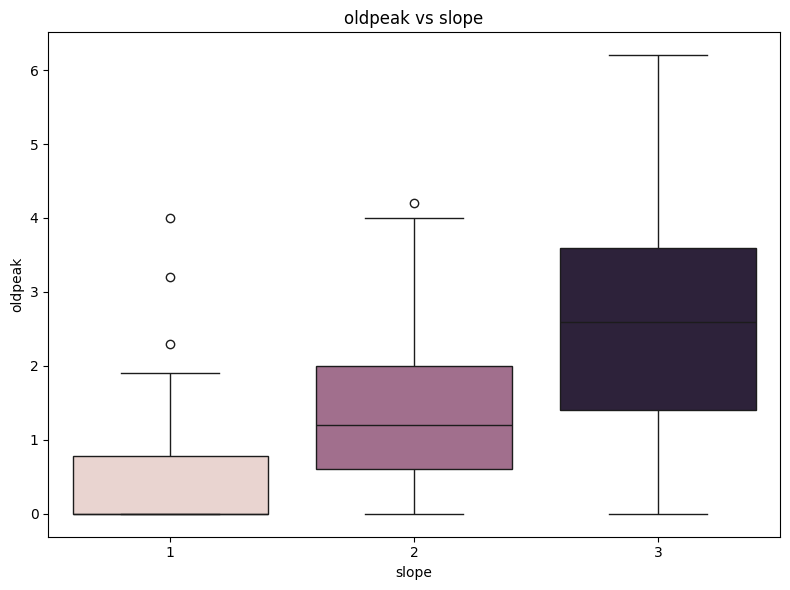

In [ ]:
for _, row in high_corr_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    plot_feature_pair(df, f1, f2)

Most input features do not show strong pairwise correlation. The main noticeable relationship is between `oldpeak` and `slope` (correlation ≈ 0.58). `thalach` also shows moderate negative relationships with some features, including `age`.

Overall, the correlation matrix does not show widespread pairwise redundancy among the features. However, feature selection will be evaluated experimentally during model development rather than based only on this correlation analysis.


### EDA Summary

## Final EDA Observations

### Data quality

* The dataset contains **303 records, 13 input features, and 1 target column**.
* Missing values were found only in `ca` (4 values, 1.32%) and `thal` (2 values, 0.66%).
* No duplicate records were found.
* The missing values were retained and replaced using mode imputation because both features contain a small number of discrete categories/counts.
* The target `num` was converted into a binary `target`, where `0` represents absence of heart disease and values `1–4` represent presence.
* The resulting input features contain no missing values after imputation.

### Target distribution

* Target `0`: **164 samples (54.13%)**
* Target `1`: **139 samples (45.87%)**
* The classes are reasonably balanced, with no severe class imbalance.
* Stratified cross-validation will be used during model evaluation to preserve the class distribution across folds.

### Feature distributions

* `age` is centered around the middle age range.
* `trestbps` and `chol` show some right skew.
* `thalach` is slightly left-skewed.
* `oldpeak` is strongly right-skewed, with many observations close to 0.
* Potential outliers are visible in `trestbps`, `chol`, `thalach`, and `oldpeak`, particularly in `chol` and `oldpeak`.
* These observations will not be removed automatically because they may represent valid patient measurements.

### Feature–target relationships

* Initial correlation screening shows the largest absolute associations with the target for `thal`, `ca`, `exang`, `oldpeak`, `thalach`, and `cp`.
* `thal`, `ca`, `exang`, `oldpeak`, and `cp` show positive associations with the binary target, while `thalach` shows a negative association.
* The feature-versus-target plots also show noticeable differences across several categorical feature groups.
* For numerical features, positive cases generally show higher `oldpeak` and lower `thalach`.
* Correlation values are treated only as an initial screening because several input variables are categorical and their encoded values do not represent continuous measurements.

### Feature–feature relationships

* Most input features do not show strong pairwise correlation.
* The strongest observed relationship is between `oldpeak` and `slope` (approximately 0.58).
* `thalach` also shows moderate negative relationships with some features, particularly `age`.
* No widespread pairwise redundancy is visible from the correlation matrix.
* Feature selection and the effect of correlated features will be evaluated experimentally during model development.

### Modeling direction

* The EDA indicates that both relatively simple feature–target relationships and possible nonlinear/interacting effects may be present.
* Therefore, **Logistic Regression** will be used as a linear baseline and **Random Forest** as a nonlinear model for the initial model comparison.
* Model performance will be evaluated using cross-validation and accuracy, precision, recall, and ROC-AUC before making further feature engineering and tuning decisions.